B.8. Implement  KNN,  Naïve  Bayes,  and  SVM  classifiers  using  Python-based  ML  tools  for 
comparison of their performance on the review sentiment classification dataset.  
 

$\textbf{KNN}$

Kth nearest neighbors(KNN) does not require any training In a way the dataset itself is the model. we are going to use the dataset itself and the nearest neighbors the predict which cluster out data belong to by calculating the euclidean distance from out point to the nearest points.   

formula for euclidean distance on n dimensions are given below: 

The Euclidean distance in n-dimensions is the straight-line distance between two points, generalized from the Pythagorean theorem: it's the square root of the sum of the squared differences between their corresponding coordinates across all n dimensions. For points $(P_{1}(x_{1},x_{2},\dots ,x_{n})) and (P_{2}(y_{1},y_{2},\dots ,y_{n})·)$, the formula is

$d(p_1,p_2)=\sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$

Formula

Points: $(P_{1}=(x_{1},x_{2},\dots ,x_{n})) and (P_{2}=(y_{1},y_{2},\dots ,y_{n}))$.

Distance: $(d(P_{1},P_{2})=\sqrt{(x_{1}-y_{1})^{2}+(x_{2}-y_{2})^{2}+\dots +(x_{n}-y_{n})^{2}})$

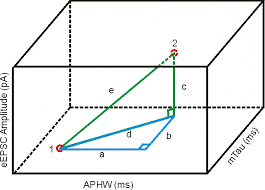

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
points = {
    'blue': [[2,4], [1,3], [2,3], [3,2], [2,1]],
    'red': [[5,6], [4,5], [4,6], [6,6], [5,4]]
}

new_point = [3,3]

In [3]:
def euclidean_dist(p,q):
    return np.sqrt(np.sum((np.array(p) - np.array(q))**2))

In [4]:
class knn:

    def __init__(self, k=3):
        self.k = k
        self.point = None

    def fit(self, points):
        self.points = points
    
    def predict(self, new_point):
        distances = []

        for category in self.points:
            for point in self.points[category]:
                distance = euclidean_dist(point,new_point)
                distances.append([distance,category])

        categories = [category[1] for category in sorted(distances)[:self.k]]
        result = Counter(categories).most_common(1)[0][0]
        return result


In [5]:
k = knn()
k.fit(points)

In [6]:
color = k.predict(new_point)

$\textbf{Visualization}$

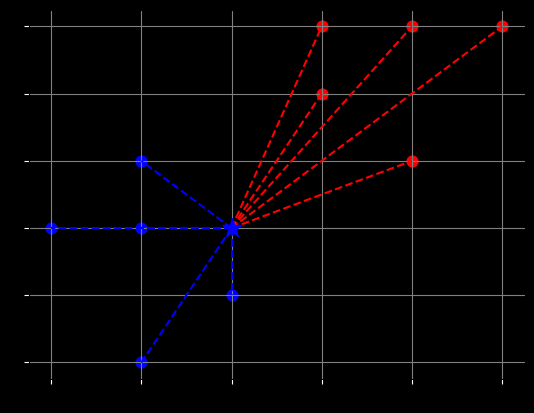

In [7]:
ax = plt.subplot()
ax.grid(True, color='gray')
ax.set_facecolor('black')
ax.figure.set_facecolor('black')
ax.tick_params(axis="x", color='white')
ax.tick_params(axis="y", color='white')

for point in points['blue']:
    ax.scatter(point[0], point[1], color='blue', s=60)

for point in points['red']:
    ax.scatter(point[0], point[1], color='red', s=60)

ax.scatter(new_point[0], new_point[1], color=color, s=200, marker="*", zorder=100)

for point in points['blue']:
    ax.plot([new_point[0], point[0]], [new_point[1],point[1]], color='blue', linestyle='--')

for point in points['red']:
    ax.plot([new_point[0], point[0]], [new_point[1],point[1]], color='red', linestyle='--')